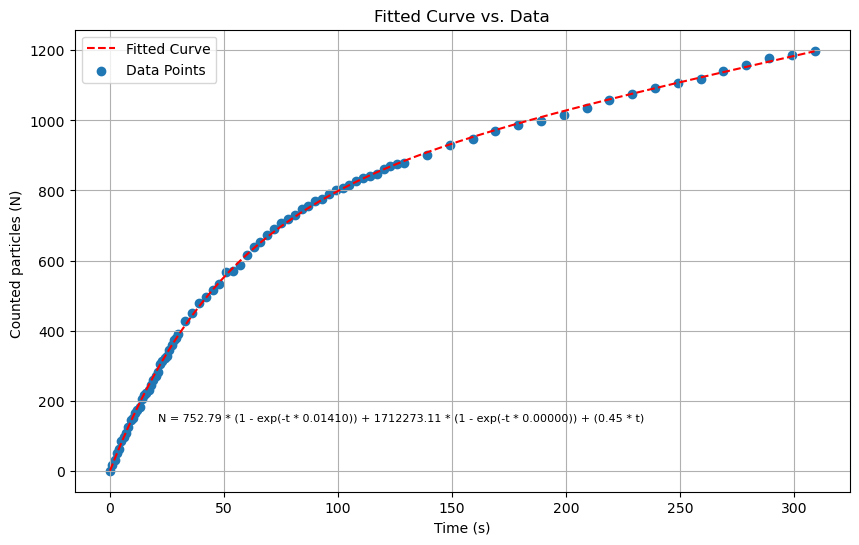

   N1 = 752.79
   N2 = 1712273.11
   T1 = 49.17 s ==> landa1 = 0.01410
   T2 = 1714752.08 s ==> landa2 = 0.00000
   N = N1 * (1 - np.exp(-t * landa1 )) + N2 * (1 - np.exp(-t * landa2)) + (r * t) 
=> N = 752.79 * (1 - exp(-t * 0.01410)) + 1712273.11 * (1 - exp(-t * 0.00000)) + (0.45 * t)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
mydict = {
    0: 0, 1: 16, 2: 30, 3: 50, 4: 61, 5: 84, 6: 96, 7: 109, 8: 126, 9: 146,
    10: 151, 11: 166, 12: 174, 13: 182, 14: 206, 15: 216, 16: 221, 17: 231,
    18: 246, 19: 260, 20: 269, 21: 282, 22: 306, 23: 312, 24: 321, 25: 328,
    26: 344, 27: 359, 28: 372, 29: 379, 30: 389, 33: 426, 36: 450, 39: 480,
    42: 496, 45: 516, 48: 534, 51: 566, 54: 571, 57: 586, 60: 617, 63: 638,
    66: 652, 69: 672, 72: 689, 75: 706, 78: 720, 81: 730, 84: 748, 87: 757,
    90: 769, 93: 776, 96: 789, 99: 801, 102: 806, 105: 817, 108: 827, 111: 837,
    114: 842, 117: 848, 120: 861, 123: 869, 126: 876, 129: 879, 139: 902,
    149: 929, 159: 947, 169: 969, 179: 986, 189: 998, 199: 1016, 209: 1036,
    219: 1059, 229: 1076, 239: 1092, 249: 1106, 259: 1119, 269: 1140, 279: 1159,
    289: 1178, 299: 1188, 309: 1199
}

df = pd.DataFrame({'x': list(mydict.keys()), 'y': list(mydict.values())})

# Background count rate from Geiger counter
r = 267 / 600  # background slope

# Define the function
def objective(x, N1, N2, T1, T2):
    return N1 * (1 - np.exp(-x / T1)) + N2 * (1 - np.exp(-x / T2)) + (r * x)

# Fitting the curve
popt, _ = curve_fit(objective, df['x'], df['y'])
N1, N2, T1, T2 = popt

# Compute decay constants 
landa1 = (np.log(2) / T1 )
landa2 = (np.log(2) / T2) 

# Plotting 
x_line = np.arange(min(df['x']), max(df['x']) + 1, 1)
y_line = objective(x_line, N1, N2, T1, T2)

plt.figure(figsize=(10, 6))
plt.plot(x_line, y_line, '--', color='red', label='Fitted Curve')
plt.scatter(df['x'], df['y'], label='Data Points')
plt.xlabel('Time (s)')
plt.ylabel('Counted particles (N) ')
plt.title('Fitted Curve vs. Data')
plt.legend()
plt.grid(True)

# Add model equation text
plt.text(21, 140,
         f'N = {N1:.2f} * (1 - exp(-t * {landa1:.5f})) + {N2:.2f} * (1 - exp(-t * {landa2:.5f})) + ({r:.2f} * t)',
         fontsize=8, color='black')

plt.show()

# Display values
print(f"   N1 = {N1:.2f}")
print(f"   N2 = {N2:.2f}")
print(f"   T1 = {T1:.2f} s ==> landa1 = {landa1:.5f}")
print(f"   T2 = {T2:.2f} s ==> landa2 = {landa2:.5f}")
print(f"   N = N1 * (1 - np.exp(-t * landa1 )) + N2 * (1 - np.exp(-t * landa2)) + (r * t) ")
print(f"=> N = {N1:.2f} * (1 - exp(-t * {landa1:.5f})) + {N2:.2f} * (1 - exp(-t * {landa2:.5f})) + ({r:.2f} * t)")


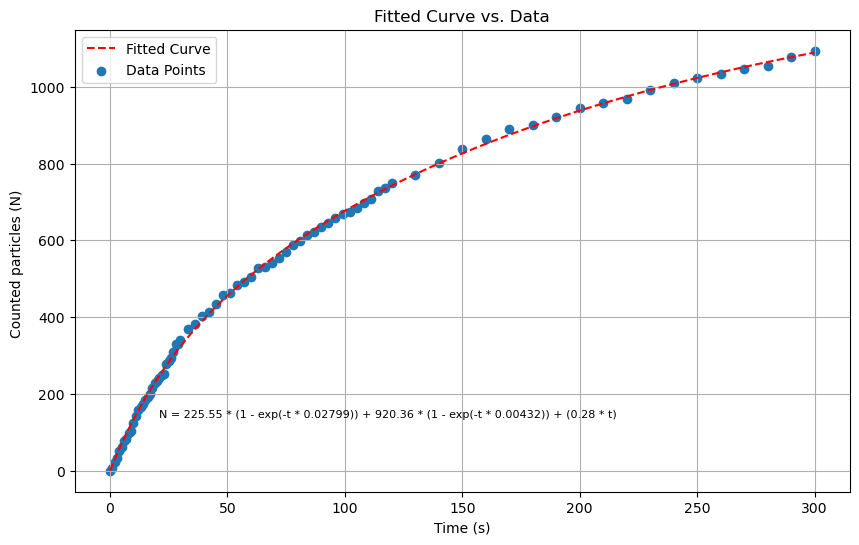

   N1 = 225.55
   N2 = 920.36
   T1 = 24.76 s ==> landa1 = 0.02799
   T2 = 160.45 s ==> landa2 = 0.00432
   N = N1 * (1 - np.exp(-t * landa1 )) + N2 * (1 - np.exp(-t * landa2)) + (r * t) 
=> N = 225.55 * (1 - exp(-t * 0.02799)) + 920.36 * (1 - exp(-t * 0.00432)) + (0.28 * t)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
mydict = {0: 0, 1: 7, 2: 24, 3: 33, 4: 52, 5: 63, 6: 77, 7: 83, 8: 99, 9: 104,
 10: 125, 11: 142, 12: 159, 13: 167, 14: 175, 15: 183, 16: 191, 17: 201, 18: 215,
  19: 229, 20: 235, 21: 241, 22: 249, 23: 253, 24: 279, 25: 285, 26: 293, 27: 309,
   28: 329, 29: 329, 30: 341, 33: 369, 36: 382, 39: 403, 42: 413, 45: 435, 48: 459,
 51: 462, 54: 483, 57: 492, 60: 505, 63: 529, 66: 531, 69: 542, 72: 555, 75: 571,
  78: 589, 81: 599, 84: 613, 87: 621, 90: 635, 93: 645, 96: 659, 99: 669, 102: 675,
   105: 685, 108: 697, 111: 707, 114: 729, 117: 737, 120: 749, 130: 771, 140: 802,
    150: 839, 160: 865, 170: 889, 180: 901, 190: 921, 200: 945, 210: 959, 220: 969,
     230: 991, 240: 1009, 250: 1022, 260: 1034, 270: 1047, 280: 1054, 290: 1077,
      300: 1094}

df = pd.DataFrame({'x': list(mydict.keys()), 'y': list(mydict.values())})

# Background count rate from Geiger counter
r = 511 / 1800  # background slope

# Define the function
def objective(x, N1, N2, T1, T2):
    return N1 * (1 - np.exp(-x / T1)) + N2 * (1 - np.exp(-x / T2)) + (r * x)

# Fitting the curve
popt, _ = curve_fit(objective, df['x'], df['y'])
N1, N2, T1, T2 = popt

# Compute decay constants 
landa1 = (np.log(2) / T1 )
landa2 = (np.log(2) / T2) 

# Plotting 
x_line = np.arange(min(df['x']), max(df['x']) + 1, 1)
y_line = objective(x_line, N1, N2, T1, T2)

plt.figure(figsize=(10, 6))
plt.plot(x_line, y_line, '--', color='red', label='Fitted Curve')
plt.scatter(df['x'], df['y'], label='Data Points')
plt.xlabel('Time (s)')
plt.ylabel('Counted particles (N) ')
plt.title('Fitted Curve vs. Data')
plt.legend()
plt.grid(True)

# Add model equation text
plt.text(21, 140,
         f'N = {N1:.2f} * (1 - exp(-t * {landa1:.5f})) + {N2:.2f} * (1 - exp(-t * {landa2:.5f})) + ({r:.2f} * t)',
         fontsize=8, color='black')

plt.show()

# Display values
print(f"   N1 = {N1:.2f}")
print(f"   N2 = {N2:.2f}")
print(f"   T1 = {T1:.2f} s ==> landa1 = {landa1:.5f}")
print(f"   T2 = {T2:.2f} s ==> landa2 = {landa2:.5f}")
print(f"   N = N1 * (1 - np.exp(-t * landa1 )) + N2 * (1 - np.exp(-t * landa2)) + (r * t) ")
print(f"=> N = {N1:.2f} * (1 - exp(-t * {landa1:.5f})) + {N2:.2f} * (1 - exp(-t * {landa2:.5f})) + ({r:.2f} * t)")


Half-life = 47.99 seconds


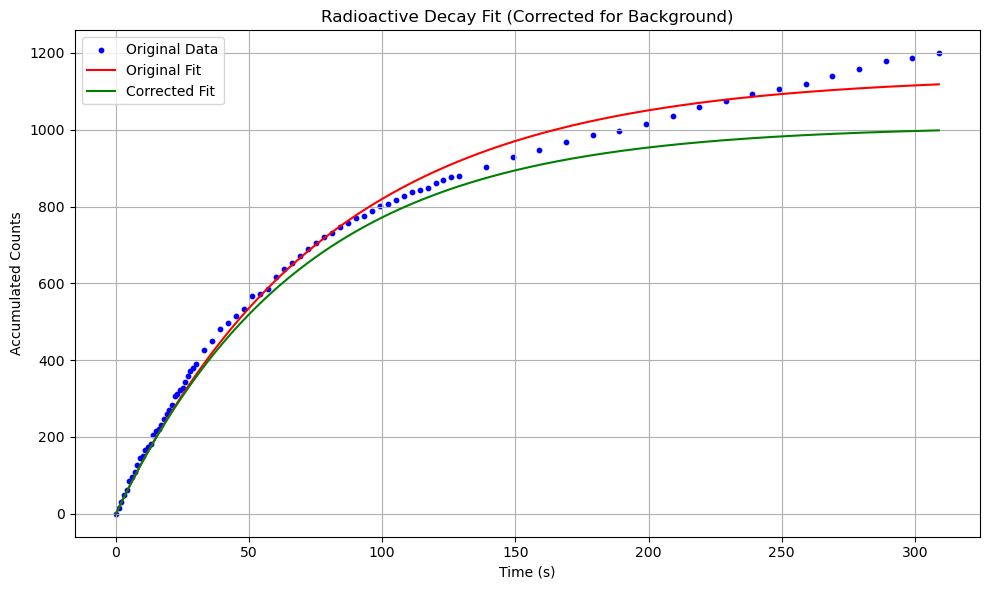

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Experimental data (time: accumulated counts)
mydict = {
    0: 0, 1: 16, 2: 30, 3: 50, 4: 61, 5: 84, 6: 96, 7: 109, 8: 126, 9: 146,
    10: 151, 11: 166, 12: 174, 13: 182, 14: 206, 15: 216, 16: 221, 17: 231,
    18: 246, 19: 260, 20: 269, 21: 282, 22: 306, 23: 312, 24: 321, 25: 328,
    26: 344, 27: 359, 28: 372, 29: 379, 30: 389, 33: 426, 36: 450, 39: 480,
    42: 496, 45: 516, 48: 534, 51: 566, 54: 571, 57: 586, 60: 617, 63: 638,
    66: 652, 69: 672, 72: 689, 75: 706, 78: 720, 81: 730, 84: 748, 87: 757,
    90: 769, 93: 776, 96: 789, 99: 801, 102: 806, 105: 817, 108: 827, 111: 837,
    114: 842, 117: 848, 120: 861, 123: 869, 126: 876, 129: 879, 139: 902,
    149: 929, 159: 947, 169: 969, 179: 986, 189: 998, 199: 1016, 209: 1036,
    219: 1059, 229: 1076, 239: 1092, 249: 1106, 259: 1119, 269: 1140, 279: 1159,
    289: 1178, 299: 1188, 309: 1199
}

# Convert to arrays
t_data = np.array(list(mydict.keys()))
N_data = np.array(list(mydict.values()))

# Background correction
background_count = 267
background_time = 600
background_rate = background_count / background_time  # counts per second
corrected_N_data = N_data - background_rate * t_data

# Define model function
def N_acc(t, N0, lam):
    return N0 * (1 - np.exp(-lam * t))

# Fit corrected data
popt_corrected, _ = curve_fit(N_acc, t_data, corrected_N_data, p0=[1200, 0.01])
N0_corr_fit, lam_corr_fit = popt_corrected

# Compute half-life
half_life = np.log(2) / lam_corr_fit
print(f"Half-life = {half_life:.2f} seconds")

# Plot
t_fit = np.linspace(0, max(t_data), 300)
N_corr_fit = N_acc(t_fit, *popt_corrected)

plt.figure(figsize=(10, 6))
plt.scatter(t_data, N_data, label='Original Data', color='blue', s=10)
plt.plot(t_fit, N_acc(t_fit, *curve_fit(N_acc, t_data, N_data, p0=[1200, 0.01])[0]), label='Original Fit', color='red')
plt.plot(t_fit, N_corr_fit, label='Corrected Fit', color='green')
plt.xlabel('Time (s)')
plt.ylabel('Accumulated Counts')
plt.title('Radioactive Decay Fit (Corrected for Background)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
